In [70]:
require(data.table)
require(tidyverse)
require(dplyr)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

## importing data as original .txt files from symportal

In [71]:
#load sample metadata skipping first row
meta=fread("/home/caroline_desouza_uml_edu/pcr_meta.csv", header=TRUE)

#asv table will have the sample names (or idenifiers), otu's and the counts for how many otu present in each sample
asv_all=fread("/scratch4/workspace/caroline_desouza_uml_edu-microbe-Run1/its2_type_profiles/658_20251216T122502_DBV_20251217T093655.profiles.relative.abund_only.txt")

#for phyloseq taxa has the otus and the taxonomic groupings for each otu
## (uid are like otu's that identify each ITS2 type profile in the SymPortal database)
taxa=read.csv("/scratch4/workspace/caroline_desouza_uml_edu-microbe-Run1/its2_type_profiles/658_20251216T122502_DBV_20251217T093655.profiles.meta_only.txt", sep = '\t',header = T)

#get sample names from sample uid
#which sample uid is which sample
#load sample metadata skipping first row
uid=fread("/scratch4/workspace/caroline_desouza_uml_edu-microbe-Run1/post_med_seqs/658_20251216T122502_DBV_20251217T093655.seqs.relative.meta_only.txt", header=TRUE)

In [72]:
head(asv_all)
head(taxa)

sample_uid,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,⋯,1665525,1665530,1667585,1669179,1668415,1667391,1669206,1668181,1667936,1668885
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
262837,0.006049276,0,0.000000000,0.0000000000,0.0000000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0.000000000
262863,0.000000000,0,0.000000000,0.0000000000,0.0055851651,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0.007228267
262785,0.000000000,0,0.009088362,0.0001438991,0.0000000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0.003589903
262825,0.000000000,0,0.000000000,0.0000000000,0.0077495890,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0.000000000
262814,0.007366015,0,0.000000000,0.0000000000,0.0000000000,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0.016392802
262822,0.000000000,0,0.000000000,0.0000000000,0.0004378632,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0.000000000


,ITS2.type.profile.UID,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,1661676,A,A3/A4/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",21,26,A3/A4/A13-A4a,22385/29206/8181-40166,0.634[0.211]/0.150[0.114]-0.111[0.095]/0.105[0.186]
2,1661811,A,A3,"Symbiodinium natans,Symbiodinium tridacnidorum",11,230,A3,22385,1.000[0.000]
3,1661272,A,A3/A4,"Symbiodinium natans,Symbiodinium tridacnidorum",10,22,A3/A4/A4a,22385/29206-40166,0.657[0.295]/0.198[0.147]-0.144[0.151]
4,1661422,A,A3bb/A3bt,None,9,322,A3bb/A3bt,,0.515[0.062]/0.485[0.062]
5,1661525,A,A3/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",8,28,A3/A13,,0.627[0.220]/0.373[0.220]
6,1661677,A,A4/A3/A4a,"Symbiodinium natans,Symbiodinium tridacnidorum",8,8,A4/A3/A4a-A4d,29206/22385/40166-29900,0.330[0.130]/0.292[0.241]/0.288[0.136]-0.089[0.061]


In [73]:
head(meta)
head(uid)

V1,MonthYear,colony,Tubelabel_species,Health_Status,Date_ITS2,Condition
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,May 2022,1_3,052022_BEL_CBC_T1_2_SSID,Healthy,6_26_2025,Diseased
2,May 2022,2_63,052022_BEL_CBC_T2_9_PAST,Healthy,6_30_2025,Healthy
3,May 2022,2_73,052022_BEL_CBC_T2_1_SSID,Healthy,7_7_2025,Healthy
4,May 2022,2_79,052022_BEL_CBC_T2_71_OFAV,Healthy,6_27_2025,Healthy
5,May 2022,3_10,052022_BEL_CBC_T3_8_PAST,Healthy,6_27_2025,Healthy
6,May 2022,3_14,052022_BEL_CBC_T3_13_MCAV,Healthy,7_11_2025,Healthy


sample_uid,sample_name,fastq_fwd_file_name,fastq_fwd_sha256_file_hash,fastq_rev_file_name,fastq_rev_sha256_file_hash,data_set_uid,data_set_name,raw_contigs,post_qc_absolute_seqs,⋯,host_phylum,host_class,host_order,host_family,host_genus,host_species,collection_latitude,collection_longitude,collection_date,collection_depth
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
262837,092023_BEL_CBC_T4_92_PSTR,092023-BEL-CBC-T4-92-PSTR_S43_R1_ITS2.fastq.gz,99ba93a8908406252b1e98fda942de2089593f6a160ff7f34bcea1ee72f1fb28,092023-BEL-CBC-T4-92-PSTR_S43_R2_ITS2.fastq.gz,49588dcd915bf52585ccbe2cf7d9cb0b113e712bc8e5ce56de82da53785b20ee,1416,20251201T204055_gignosa1,1.229599,1.034001,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.77976,-88.10117,202309,5
262863,122023_BEL_CBC_T3_531_PSTR,122023-BEL-CBC-T3-531-PSTR_S28_R1_ITS2.fastq.gz,5620104dc0444cdce8ecbb495940109f67716cd0f2f6c57c74ded251ffc9678b,122023-BEL-CBC-T3-531-PSTR_S28_R2_ITS2.fastq.gz,e830e741566af4bd5b5ebd0dbf10005bd653b415ffbb01d9fcb89f75386d706c,1416,20251201T204055_gignosa1,1.098625,1.042822,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202312,5
262785,022024_BEL_CBC_T3_851_PSTR,022024-BEL-CBC-T3-851-PSTR_S13_R1_ITS2.fastq.gz,7159e39f8dfbe066c1873201893c1ceadac4b34f6e1b27c28077aa2886cfce53,022024-BEL-CBC-T3-851-PSTR_S13_R2_ITS2.fastq.gz,594e53d5001c7c7050627f5d37cfdfa08ef452dc20a81ac7ff81fe4c252e6350,1416,20251201T204055_gignosa1,1.148951,1.056143,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202402,5
262825,082024_BEL_CBC_T4_1606_PSTR,082024-BEL-CBC-T4-1606-PSTR_S25_R1_ITS2.fastq.gz,4cf8992c93e9976cba36fa4580ca2d8bce1a18e84fb1d9815159e27f20e1807b,082024-BEL-CBC-T4-1606-PSTR_S25_R2_ITS2.fastq.gz,03502a19c81936eb131c92f733c96e9695933319e948ae9fb97db54f6ed7e03f,1416,20251201T204055_gignosa1,1.100288,1.043913,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.77976,-88.10117,202408,5
262814,062024_BEL_CBC_T3_1433_PSTR,062024-BEL-CBC-T3-1433-PSTR_S2_R1_ITS2.fastq.gz,11f26b7fe3024fd476d4a807cf13cb17ff8fcd418fa582868168e44e9fa9b68d,062024-BEL-CBC-T3-1433-PSTR_S2_R2_ITS2.fastq.gz,b05072c8f8b13d5d760f8b3c1b68353d04bf57cea99f7fc95c873da0f62e4972,1416,20251201T204055_gignosa1,1.136906,1.051132,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202406,5
262822,082024_BEL_CBC_T3_1560_PSTR,082024-BEL-CBC-T3-1560-PSTR_S54_R1_ITS2.fastq.gz,54b6ae89f38ce8d86b1175eef7ef0c91e9942765d7e4e0708166aeb2b1ffc925,082024-BEL-CBC-T3-1560-PSTR_S54_R2_ITS2.fastq.gz,1c5e4138334d34ce40a47c7084983d63303544d518aea4ee536190b937200c8a,1416,20251201T204055_gignosa1,1.106850,1.050226,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202408,5


In [74]:
class(meta)
class(uid)
# Rename a single column
setnames(uid, "sample_name", "Tubelabel_species")

[1] "data.table" "data.frame"

[1] "data.table" "data.frame"

In [75]:
colnames(uid)

[1] "sample_uid"                                    
 [2] "Tubelabel_species"                             
 [3] "fastq_fwd_file_name"                           
 [4] "fastq_fwd_sha256_file_hash"                    
 [5] "fastq_rev_file_name"                           
 [6] "fastq_rev_sha256_file_hash"                    
 [7] "data_set_uid"                                  
 [8] "data_set_name"                                 
 [9] "raw_contigs"                                   
[10] "post_qc_absolute_seqs"                         
[11] "post_qc_unique_seqs"                           
[12] "post_taxa_id_absolute_symbiodiniaceae_seqs"    
[13] "post_taxa_id_unique_symbiodiniaceae_seqs"      
[14] "size_screening_violation_absolute"             
[15] "size_screening_violation_unique"               
[16] "post_taxa_id_absolute_non_symbiodiniaceae_seqs"
[17] "post_taxa_id_unique_non_symbiodiniaceae_seqs"  
[18] "post_med_absolute"                             
[19] "post_med_unique"                               
[20] "noName Clade A"                                
[21] "noName Clade B"                                
[22] "noName Clade C"                                
[23] "noName Clade D"                                
[24] "noName Clade E"                                
[25] "noName Clade F"                                
[26] "noName Clade G"                                
[27] "noName Clade H"                                
[28] "noName Clade I"                                
[29] "sample_type"                                   
[30] "host_phylum"                                   
[31] "host_class"                                    
[32] "host_order"                                    
[33] "host_family"                                   
[34] "host_genus"                                    
[35] "host_species"                                  
[36] "collection_latitude"                           
[37] "collection_longitude"                          
[38] "collection_date"                               
[39] "collection_depth"

In [76]:
uid_clean <- uid[, c("sample_uid", "Tubelabel_species", "data_set_uid", "host_family", "host_genus", "host_species", "collection_date", "collection_depth")]

In [77]:
# Merge by the common column "ID" (default is inner join)
meta <- merge(meta, uid_clean, by = "Tubelabel_species")
head(meta)

Tubelabel_species,V1,MonthYear,colony,Health_Status,Date_ITS2,Condition,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,86,Jan 2024,1_3,Healthy,7_7_2025,Healthy,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8
012024_BEL_CBC_T1_563_PSTR,85,Jan 2024,1_12,Healthy,7_7_2025,Healthy,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8
012024_BEL_CBC_T2_601_OFAV,87,Jan 2024,2_79,Healthy,7_7_2025,Healthy,262773,1416,Merulinidae,Orbicella,faveolata,202401,7
012024_BEL_CBC_T2_605_SSID,88,Jan 2024,2_99,Healthy,7_10_2025,CLB,262774,1416,Rhizangiidae,Siderastrea,sidera,202401,7
012024_BEL_CBC_T3_627_PAST,91,Jan 2024,3_34,Healthy,7_10_2025,Healthy,262775,1416,Poritidae,Porites,asteroides,202401,5
012024_BEL_CBC_T3_631_MCAV,90,Jan 2024,3_21,Healthy,7_7_2025,Healthy,262776,1416,Montastraeidae,Montastrea,cavernosa,202401,5


### cleaning meta data

In [78]:
#cleaning samdt 
meta <- meta[, c("V1" ) := NULL]
meta <- meta[meta$Date_ITS2 != 'NA', ]
# Create a new data frame with the species, date, and transect columns
# Example samdt (make sure your data is a data.table)
setDT(meta)
# Split Tubelabel_species by "_" and assign new columns
meta[, c("transect", "species_code") := {
  parts <- strsplit(Tubelabel_species, "_")
  list(
    sapply(parts, `[`, 4),  # transect is 4th element
    sapply(parts, `[`, 6)   # species is 6th element
  )
}]

In [79]:
head(meta)

Tubelabel_species,MonthYear,colony,Health_Status,Date_ITS2,Condition,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,transect,species_code
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
012024_BEL_CBC_T1_557_SSID,Jan 2024,1_3,Healthy,7_7_2025,Healthy,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,T1,SSID
012024_BEL_CBC_T1_563_PSTR,Jan 2024,1_12,Healthy,7_7_2025,Healthy,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,T1,PSTR
012024_BEL_CBC_T2_601_OFAV,Jan 2024,2_79,Healthy,7_7_2025,Healthy,262773,1416,Merulinidae,Orbicella,faveolata,202401,7,T2,OFAV
012024_BEL_CBC_T2_605_SSID,Jan 2024,2_99,Healthy,7_10_2025,CLB,262774,1416,Rhizangiidae,Siderastrea,sidera,202401,7,T2,SSID
012024_BEL_CBC_T3_627_PAST,Jan 2024,3_34,Healthy,7_10_2025,Healthy,262775,1416,Poritidae,Porites,asteroides,202401,5,T3,PAST
012024_BEL_CBC_T3_631_MCAV,Jan 2024,3_21,Healthy,7_7_2025,Healthy,262776,1416,Montastraeidae,Montastrea,cavernosa,202401,5,T3,MCAV


In [80]:
#use date collected as a date column for chronological order
meta$DateFormatted <- as.Date(
  paste0(meta$collection_date, "01"),
  format = "%Y%m%d"
)
meta$MonthYear <- format(meta$DateFormatted, "%b %Y")

meta$MonthYear <- factor(
  meta$MonthYear,
  levels = unique(meta$MonthYear[order(meta$DateFormatted)])
)

### cleaning asv_all

In [81]:
class(asv_all)

[1] "data.table" "data.frame"

In [82]:
#new df with just sample_uid with Tubelabel_species
name <- uid_clean <- uid[, c("sample_uid", "Tubelabel_species")]

#replace sample_uid with tubelable_species in asv_all
# Merge by the common column "ID" (default is inner join)
asv_all <- merge(asv_all, name, by = "sample_uid")
head(asv_all)

sample_uid,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,⋯,1665530,1667585,1669179,1668415,1667391,1669206,1668181,1667936,1668885,Tubelabel_species
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
262771,0.000000000,0,0,0,0,0,0.0000000,0,0,⋯,0,0,0,0,0.0000000,0,0,0,0,012024_BEL_CBC_T1_557_SSID
262772,0.000000000,0,0,0,0,0,0.0000000,0,0,⋯,0,0,0,0,0.0000000,0,0,0,0,012024_BEL_CBC_T1_563_PSTR
262773,0.000000000,0,0,0,0,0,0.0000000,0,0,⋯,0,0,0,0,0.0000000,0,0,0,0,012024_BEL_CBC_T2_601_OFAV
262774,0.005449668,0,0,0,0,0,0.0000000,0,0,⋯,0,0,0,0,0.1612674,0,0,0,0,012024_BEL_CBC_T2_605_SSID
262775,0.000000000,0,0,0,0,0,0.7647625,0,0,⋯,0,0,0,0,0.0000000,0,0,0,0,012024_BEL_CBC_T3_627_PAST
262776,0.003395677,0,0,0,0,0,0.0000000,0,0,⋯,0,0,0,0,0.0000000,0,0,0,0,012024_BEL_CBC_T3_631_MCAV


In [83]:
#bringing Tubelabel_species to the front
asv_nouid <- asv_all[, c("sample_uid" ) := NULL]
setcolorder(asv_nouid, c("Tubelabel_species"))
asvdf <- as.data.frame(asv_nouid)   
asvdf <- data.frame(asvdf, row.names = 1, check.names = FALSE)
head(asvdf)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,1665525,1665530,1667585,1669179,1668415,1667391,1669206,1668181,1667936,1668885
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
012024_BEL_CBC_T1_557_SSID,0.000000000,0,0,0,0,0,0.0000000,0,0,0,⋯,0,0,0,0,0,0.0000000,0,0,0,0
012024_BEL_CBC_T1_563_PSTR,0.000000000,0,0,0,0,0,0.0000000,0,0,0,⋯,0,0,0,0,0,0.0000000,0,0,0,0
012024_BEL_CBC_T2_601_OFAV,0.000000000,0,0,0,0,0,0.0000000,0,0,0,⋯,0,0,0,0,0,0.0000000,0,0,0,0
012024_BEL_CBC_T2_605_SSID,0.005449668,0,0,0,0,0,0.0000000,0,0,0,⋯,0,0,0,0,0,0.1612674,0,0,0,0
012024_BEL_CBC_T3_627_PAST,0.000000000,0,0,0,0,0,0.7647625,0,0,0,⋯,0,0,0,0,0,0.0000000,0,0,0,0
012024_BEL_CBC_T3_631_MCAV,0.003395677,0,0,0,0,0,0.0000000,0,0,0,⋯,0,0,0,0,0,0.0000000,0,0,0,0


In [84]:
# align rownames and columns
#optional to set rownames
metadf <- as.data.frame(meta)              # Convert to data.frame (from data.table)
rownames(metadf) <- metadf$Tubelabel_species # Set rownames
metadf$Tubelabel_species <- NULL    
head(metadf)

,MonthYear,colony,Health_Status,Date_ITS2,Condition,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,transect,species_code,DateFormatted
,<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Jan 2024,1_3,Healthy,7_7_2025,Healthy,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,T1,SSID,2024-01-01
012024_BEL_CBC_T1_563_PSTR,Jan 2024,1_12,Healthy,7_7_2025,Healthy,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,T1,PSTR,2024-01-01
012024_BEL_CBC_T2_601_OFAV,Jan 2024,2_79,Healthy,7_7_2025,Healthy,262773,1416,Merulinidae,Orbicella,faveolata,202401,7,T2,OFAV,2024-01-01
012024_BEL_CBC_T2_605_SSID,Jan 2024,2_99,Healthy,7_10_2025,CLB,262774,1416,Rhizangiidae,Siderastrea,sidera,202401,7,T2,SSID,2024-01-01
012024_BEL_CBC_T3_627_PAST,Jan 2024,3_34,Healthy,7_10_2025,Healthy,262775,1416,Poritidae,Porites,asteroides,202401,5,T3,PAST,2024-01-01
012024_BEL_CBC_T3_631_MCAV,Jan 2024,3_21,Healthy,7_7_2025,Healthy,262776,1416,Montastraeidae,Montastrea,cavernosa,202401,5,T3,MCAV,2024-01-01


In [85]:
#make sure rownames are in same order
common_samples <- intersect(rownames(metadf), rownames(asvdf))

# Reorder both objects to match the same order
metadf <- metadf[common_samples, , drop = FALSE]
asvdf <- asvdf[common_samples, , drop = FALSE]

In [86]:
# align rownames and columns
#optional to set rownames
taxadf <- as.data.frame(taxa)              # Convert to data.frame (from data.table)
rownames(taxadf) <- taxadf$ITS2.type.profile.UID # Set rownames
taxadf$ITS2.type.profile.UID <- NULL    
head(taxadf)

,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1661676,A,A3/A4/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",21,26,A3/A4/A13-A4a,22385/29206/8181-40166,0.634[0.211]/0.150[0.114]-0.111[0.095]/0.105[0.186]
1661811,A,A3,"Symbiodinium natans,Symbiodinium tridacnidorum",11,230,A3,22385,1.000[0.000]
1661272,A,A3/A4,"Symbiodinium natans,Symbiodinium tridacnidorum",10,22,A3/A4/A4a,22385/29206-40166,0.657[0.295]/0.198[0.147]-0.144[0.151]
1661422,A,A3bb/A3bt,None,9,322,A3bb/A3bt,,0.515[0.062]/0.485[0.062]
1661525,A,A3/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",8,28,A3/A13,,0.627[0.220]/0.373[0.220]
1661677,A,A4/A3/A4a,"Symbiodinium natans,Symbiodinium tridacnidorum",8,8,A4/A3/A4a-A4d,29206/22385/40166-29900,0.330[0.130]/0.292[0.241]/0.288[0.136]-0.089[0.061]


In [87]:
# Reorder taxa to match asv_all
#Get common ASVs
common_asvs <- intersect(colnames(asvdf), rownames(taxadf))

# Subset both
asvdf <- asvdf[, common_asvs]
taxadf <- taxadf[common_asvs, ]

In [88]:
# final checks

#double check that all rownames match
all(rownames(asvdf) %in% rownames(metadf))  # Should be TRUE
all(rownames(metadf) %in% rownames(asvdf))  # Should be TRUE

sum(is.na(match(colnames(asvdf), rownames(taxadf))))
identical(colnames(asvdf), rownames(taxadf))  # Should be TRUE

#check if asv_all is numeric
all(sapply(as.data.table(asvdf), is.numeric))

identical(colnames(asvdf), rownames(taxadf))  # MUST be TRUE
identical(rownames(asvdf), rownames(metadf))  # MUST be TRUE

[1] TRUE

[1] TRUE

[1] 0

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

## build phyloseq object

In [89]:
taxa_mat <- as.matrix(taxadf)

In [90]:
# Convert asv_all to otu_table (specify taxa_are_rows = TRUE/FALSE depending on your data)
otu <- otu_table(asvdf, taxa_are_rows = FALSE)  # or TRUE if taxa in rows

# Sample metadata as sample_data
sam <- sample_data(metadf)

profile=tax_table(taxa_mat)

# Construct phyloseq object
ps <- phyloseq(otu, sam, profile)

In [91]:
ps
saveRDS(ps, file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_ITS2_outputs/RDS/Run1_ps.rds")

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 73 taxa and 94 samples ]
sample_data() Sample Data:       [ 94 samples by 15 sample variables ]
tax_table()   Taxonomy Table:    [ 73 taxa by 8 taxonomic ranks ]

## taxa

In [92]:
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)

In [93]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps, function(x) 1E6 * x / sum(x))

In [94]:
head(sample_data(ps_norm))
head(tax_table(ps_norm))

,MonthYear,colony,Health_Status,Date_ITS2,Condition,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,transect,species_code,DateFormatted
,<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Jan 2024,1_3,Healthy,7_7_2025,Healthy,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,T1,SSID,2024-01-01
012024_BEL_CBC_T1_563_PSTR,Jan 2024,1_12,Healthy,7_7_2025,Healthy,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,T1,PSTR,2024-01-01
012024_BEL_CBC_T2_601_OFAV,Jan 2024,2_79,Healthy,7_7_2025,Healthy,262773,1416,Merulinidae,Orbicella,faveolata,202401,7,T2,OFAV,2024-01-01
012024_BEL_CBC_T2_605_SSID,Jan 2024,2_99,Healthy,7_10_2025,CLB,262774,1416,Rhizangiidae,Siderastrea,sidera,202401,7,T2,SSID,2024-01-01
012024_BEL_CBC_T3_627_PAST,Jan 2024,3_34,Healthy,7_10_2025,Healthy,262775,1416,Poritidae,Porites,asteroides,202401,5,T3,PAST,2024-01-01
012024_BEL_CBC_T3_631_MCAV,Jan 2024,3_21,Healthy,7_7_2025,Healthy,262776,1416,Montastraeidae,Montastrea,cavernosa,202401,5,T3,MCAV,2024-01-01


,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
1661676,A,A3/A4/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",21,26,A3/A4/A13-A4a,22385/29206/8181-40166,0.634[0.211]/0.150[0.114]-0.111[0.095]/0.105[0.186]
1661811,A,A3,"Symbiodinium natans,Symbiodinium tridacnidorum",11,230,A3,22385,1.000[0.000]
1661272,A,A3/A4,"Symbiodinium natans,Symbiodinium tridacnidorum",10,22,A3/A4/A4a,22385/29206-40166,0.657[0.295]/0.198[0.147]-0.144[0.151]
1661422,A,A3bb/A3bt,None,9,322,A3bb/A3bt,,0.515[0.062]/0.485[0.062]
1661525,A,A3/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",8,28,A3/A13,,0.627[0.220]/0.373[0.220]
1661677,A,A4/A3/A4a,"Symbiodinium natans,Symbiodinium tridacnidorum",8,8,A4/A3/A4a-A4d,29206/22385/40166-29900,0.330[0.130]/0.292[0.241]/0.288[0.136]-0.089[0.061]


### repeated colonies

In [95]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm) {
  sd <- sample_data(ps_norm)
  return(as(sd,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample <- pssd2veg(ps_norm)

In [96]:
sample <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample$SampleID <- rownames(sample)

In [97]:
# Return names which have more than one row of data
# Now filter
sample_clean <- sample %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#how many colonies are represented?
nrow(sample)
nrow(sample_clean)

[1] 94

[1] 88

In [98]:
sample_clean <- as.data.frame(sample_clean)
class(sample_clean)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

## dates in chron order

In [99]:
# 1. create proper Date variable
sample_clean$MonthYearDate <- as.Date(
  paste0("01 ", sample_clean$MonthYear),
  format = "%d %b %Y"
)

# 2. reorder MonthYear as a factor in chronological order
sample_clean$MonthYear <- factor(
  sample_clean$MonthYear,
  levels = unique(sample_clean$MonthYear[order(sample_clean$MonthYearDate)])
)

In [100]:
# Restore rownames
rownames(sample_clean) <- sample_clean$SampleID
#check
head(rownames(sample_clean))
NROW(sample_names(ps_norm))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_563_PSTR"
[3] "012024_BEL_CBC_T2_601_OFAV" "012024_BEL_CBC_T2_605_SSID"
[5] "012024_BEL_CBC_T3_627_PAST" "012024_BEL_CBC_T3_631_MCAV"

[1] 94

In [101]:
keep_samples <- rownames(sample_clean)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm_nomit
sum(keep_samples %in% sample_names(ps_norm))  # Should be 88

# Prune to keep only those samples
ps_colony <- prune_samples(sample_names(ps_norm) %in% keep_samples, ps_norm)

#checks on new ps object
class(ps_colony)
nrow(sample_data(ps_colony))
all(rownames(sample_clean) %in% sample_names(ps_colony))

[1] 88

[1] 88

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 88

[1] TRUE

In [102]:
#take the filtered metadata I just worked on — with cleaned rows, and correct sample names — and replace the old sample data in ps_clean with this cleaned version
sd_clean <- phyloseq::sample_data(sample_clean)
sample_data(ps_colony) <- sd_clean
head(sample_data(ps_colony))

,MonthYear,colony,Health_Status,Date_ITS2,Condition,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,transect,species_code,DateFormatted,SampleID,MonthYearDate
,<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<date>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Jan 2024,1_3,Healthy,7_7_2025,Healthy,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,T1,SSID,2024-01-01,012024_BEL_CBC_T1_557_SSID,2024-01-01
012024_BEL_CBC_T1_563_PSTR,Jan 2024,1_12,Healthy,7_7_2025,Healthy,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,T1,PSTR,2024-01-01,012024_BEL_CBC_T1_563_PSTR,2024-01-01
012024_BEL_CBC_T2_601_OFAV,Jan 2024,2_79,Healthy,7_7_2025,Healthy,262773,1416,Merulinidae,Orbicella,faveolata,202401,7,T2,OFAV,2024-01-01,012024_BEL_CBC_T2_601_OFAV,2024-01-01
012024_BEL_CBC_T2_605_SSID,Jan 2024,2_99,Healthy,7_10_2025,CLB,262774,1416,Rhizangiidae,Siderastrea,sidera,202401,7,T2,SSID,2024-01-01,012024_BEL_CBC_T2_605_SSID,2024-01-01
012024_BEL_CBC_T3_627_PAST,Jan 2024,3_34,Healthy,7_10_2025,Healthy,262775,1416,Poritidae,Porites,asteroides,202401,5,T3,PAST,2024-01-01,012024_BEL_CBC_T3_627_PAST,2024-01-01
012024_BEL_CBC_T3_631_MCAV,Jan 2024,3_21,Healthy,7_7_2025,Healthy,262776,1416,Montastraeidae,Montastrea,cavernosa,202401,5,T3,MCAV,2024-01-01,012024_BEL_CBC_T3_631_MCAV,2024-01-01


In [103]:
table(sample_data(ps_colony)[,"colony"])

colony
1_12  1_2 1_21 1_24 1_25  1_3 2_55 2_60 2_63 2_68 2_69 2_73 2_76 2_79 2_99 3_10 
   3    2    2    3    3    3    2    3    2    2    3    3    3    3    2    3 
3_14  3_2 3_21 3_34 3_38 3_39  3_5  3_6 3_66 3_70 4_30 4_76 4_78 4_79 4_98 
   3    3    4    2    3    4    2    3    3    6    2    3    2    2    4 

## ITS2 profile plot

In [36]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_colony)[, "ITS2.type.profile"]))

[1] 73

In [37]:
# doesnt need to be reduced to top 50
ps_its2=tax_glom(ps_colony, taxrank= "ITS2.type.profile")


In [38]:
#assigning colors
its2colors= colorRampPalette(brewer.pal(8, "Accent"))(73)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
its2 <- unique(tax_table(ps_its2)[, "ITS2.type.profile"])
    its2colors <- sample(its2colors, 73, length(its2))
    # naming my color palette so the random order stays the same
    its2colors<- setNames(its2colors, its2)

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 219 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 219 rows containing missing values or values outside the scale range
(`geom_bar()`).”


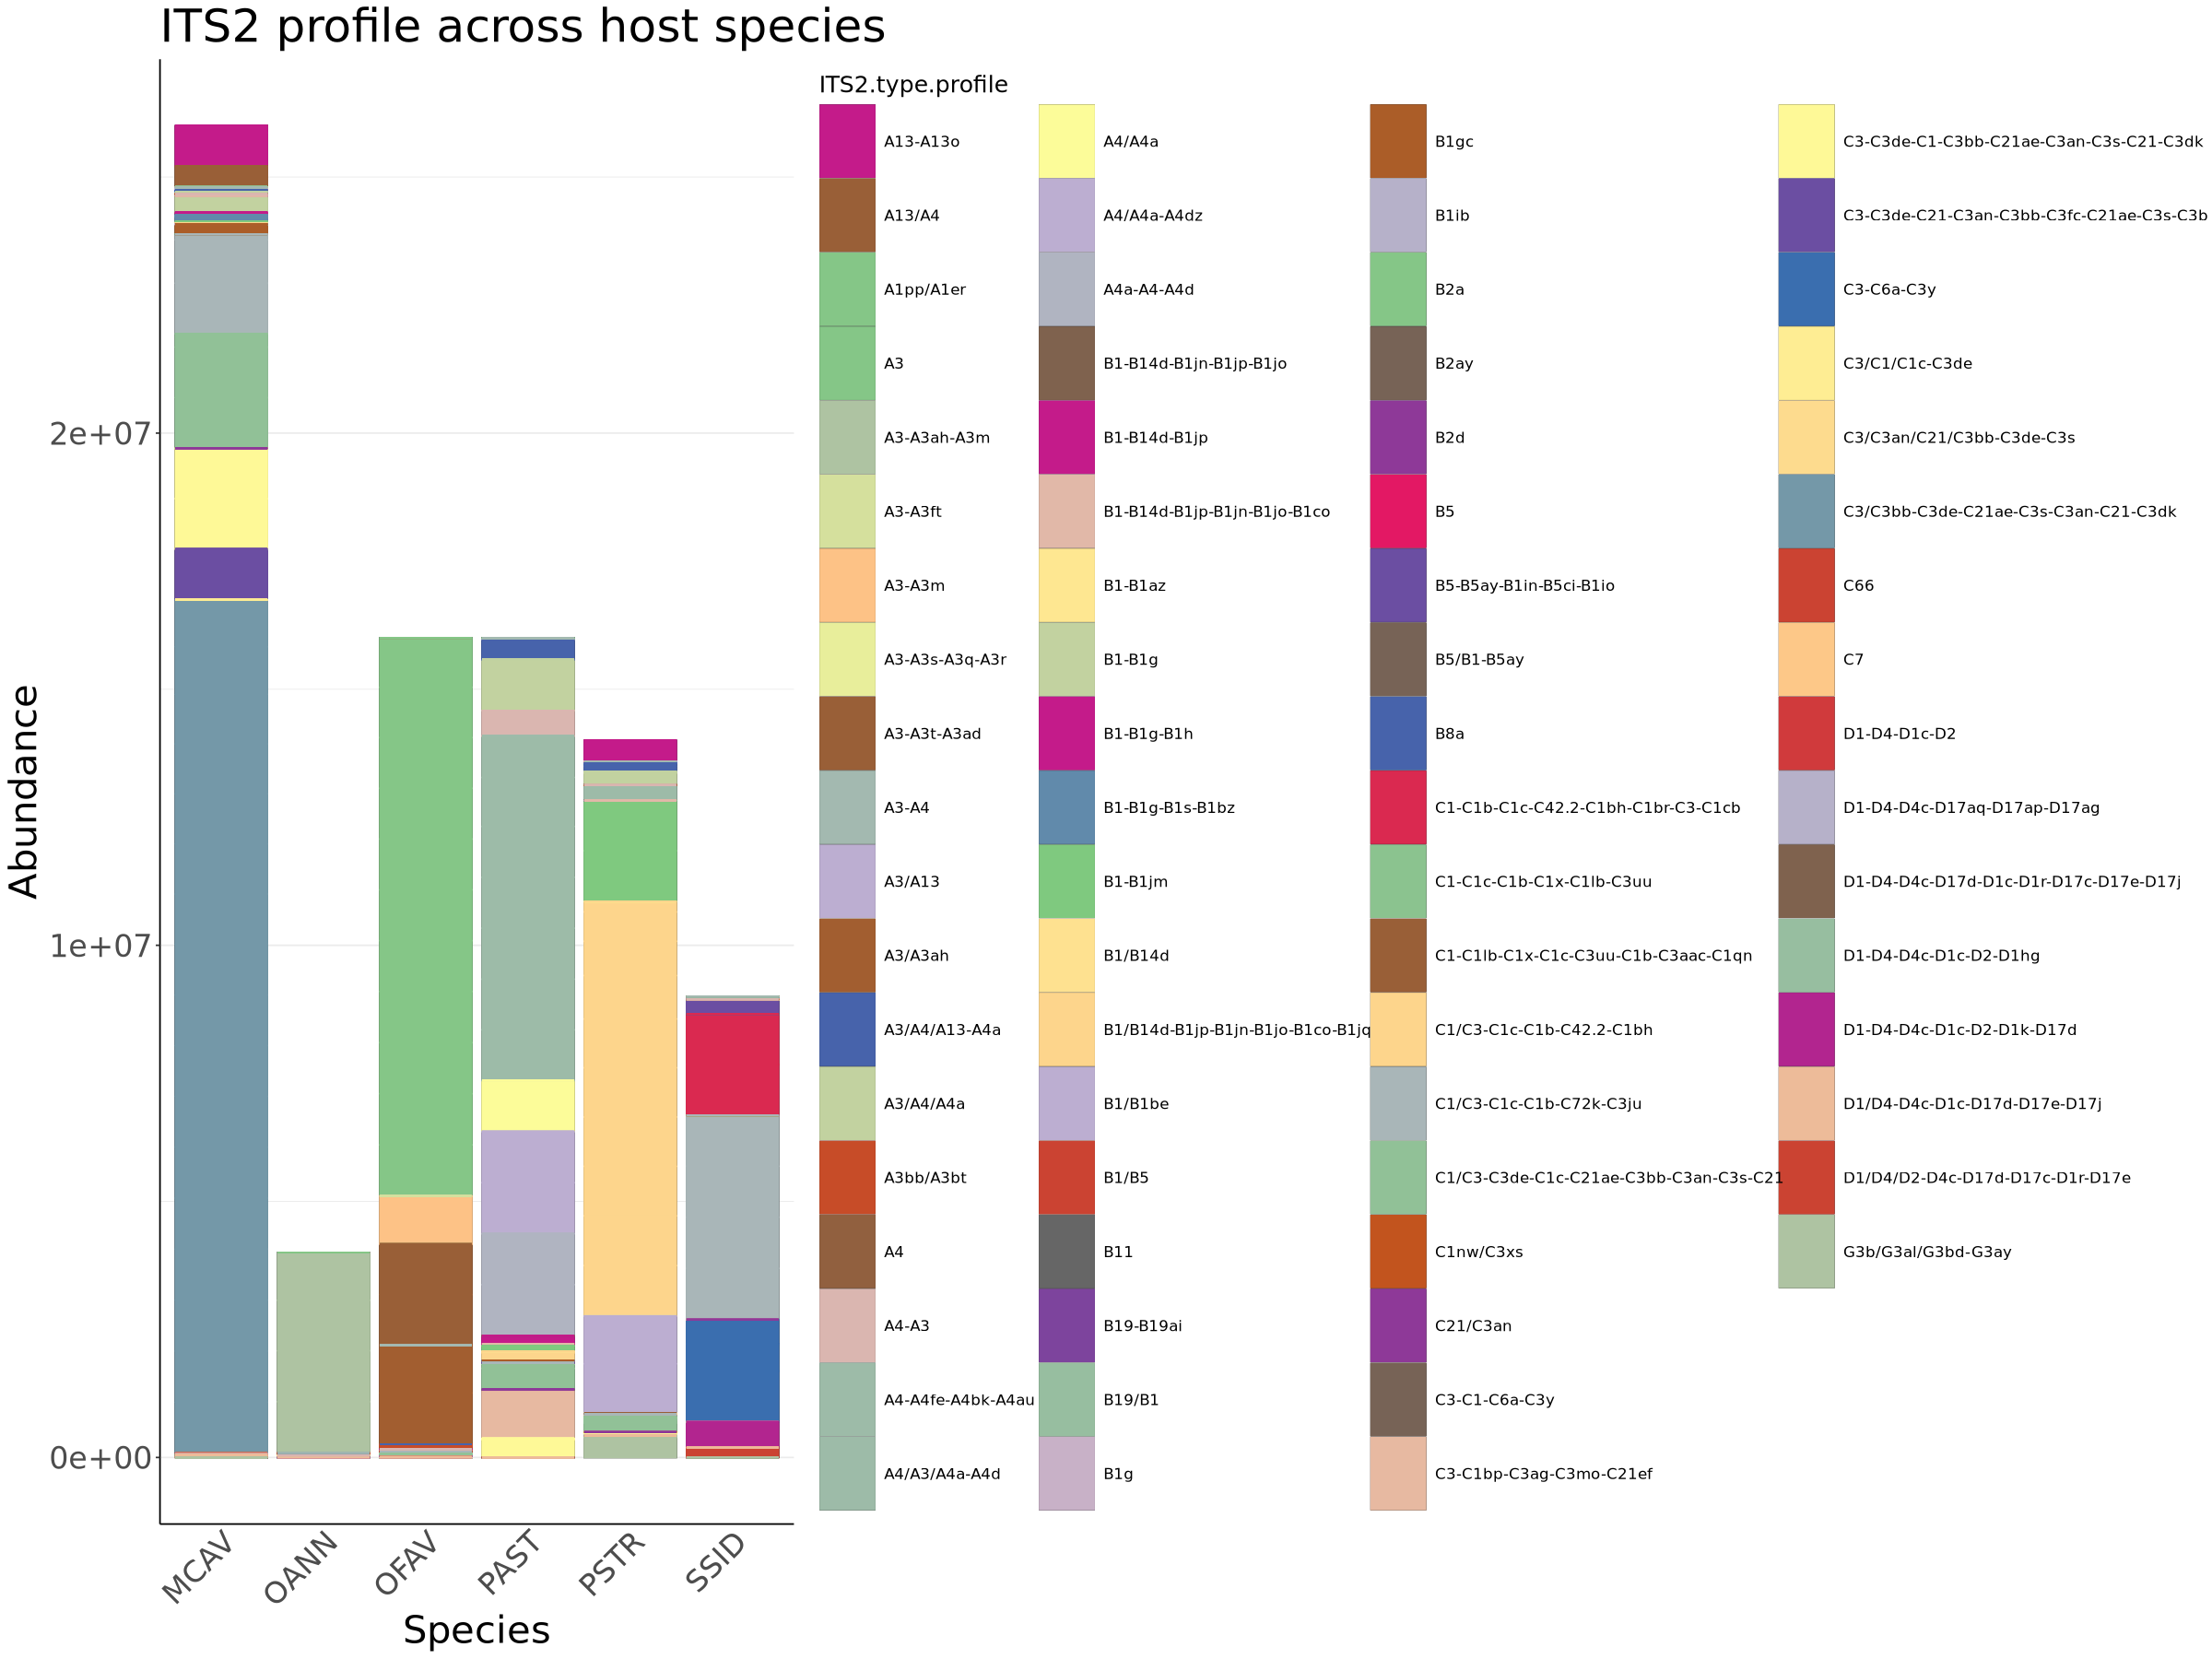

In [46]:
profile <- plot_bar(ps_its2, x="species_code", fill = "ITS2.type.profile") +
  geom_bar(aes(color = ITS2.type.profile, fill = ITS2.type.profile), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profile across host species",
       x = "Species",
       y = "Abundance",
       color = "ITS2.type.profile") +
  scale_fill_manual(values = its2colors, drop = TRUE) +
  scale_color_manual(values = its2colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
profile

## troubleshooting clade plot

In [104]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_colony)[, "Clade"]))

rank_names(ps_colony)
sum(is.na(tax_table(ps_colony)[, "Clade"]))

#check if clade is a factor
class(tax_table(ps_colony)[, "Clade"])

taxmat <- as(tax_table(ps_colony), "matrix")
tax_table(ps_colony) <- tax_table(taxmat)
class(as(tax_table(ps_colony), "matrix")[, "Clade"])


[1] 5

[1] "Clade"                                            
[2] "Majority.ITS2.sequence"                           
[3] "Associated.species"                               
[4] "ITS2.profile.abundance.local"                     
[5] "ITS2.profile.abundance.DB"                        
[6] "ITS2.type.profile"                                
[7] "Sequence.accession...SymPortal.UID"               
[8] "Average.defining.sequence.proportions.and..stdev."

[1] 0

[1] "taxonomyTable"
attr(,"package")
[1] "phyloseq"

[1] "character"

In [106]:
# isolate clade here in a new ps object
ps_clade <- tax_glom(ps_colony, taxrank = "Clade", NArm = FALSE)

ERROR: Error in merge_taxa.indices.internal(x, eqtaxa, archetype): invalid archetype provided.


In [67]:
#assigning colors
cladecolors= colorRampPalette(brewer.pal(8, "Set2"))(5)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
clade <- unique(tax_table(ps_clade)[, "Clade"])
    cladecolors <- sample(cladecolors, 5, length(clade))
    # naming my color palette so the random order stays the same
    cladecolors<- setNames(cladecolors, clade)

In [68]:
head(tax_table(ps_clade))
head(sample_data(ps_clade))

,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
1661676,NA,NA,NA,NA,NA,NA,NA,NA


,MonthYear,colony,Health_Status,Date_ITS2,Condition,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,transect,species_code,DateFormatted,SampleID,MonthYearDate
,<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<date>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Jan 2024,1_3,Healthy,7_7_2025,Healthy,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,T1,SSID,2024-01-01,012024_BEL_CBC_T1_557_SSID,2024-01-01
012024_BEL_CBC_T1_563_PSTR,Jan 2024,1_12,Healthy,7_7_2025,Healthy,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,T1,PSTR,2024-01-01,012024_BEL_CBC_T1_563_PSTR,2024-01-01
012024_BEL_CBC_T2_601_OFAV,Jan 2024,2_79,Healthy,7_7_2025,Healthy,262773,1416,Merulinidae,Orbicella,faveolata,202401,7,T2,OFAV,2024-01-01,012024_BEL_CBC_T2_601_OFAV,2024-01-01
012024_BEL_CBC_T2_605_SSID,Jan 2024,2_99,Healthy,7_10_2025,CLB,262774,1416,Rhizangiidae,Siderastrea,sidera,202401,7,T2,SSID,2024-01-01,012024_BEL_CBC_T2_605_SSID,2024-01-01
012024_BEL_CBC_T3_627_PAST,Jan 2024,3_34,Healthy,7_10_2025,Healthy,262775,1416,Poritidae,Porites,asteroides,202401,5,T3,PAST,2024-01-01,012024_BEL_CBC_T3_627_PAST,2024-01-01
012024_BEL_CBC_T3_631_MCAV,Jan 2024,3_21,Healthy,7_7_2025,Healthy,262776,1416,Montastraeidae,Montastrea,cavernosa,202401,5,T3,MCAV,2024-01-01,012024_BEL_CBC_T3_631_MCAV,2024-01-01


In [63]:
clade <- plot_bar(ps_clade, x="species_code", fill = "Clade") +
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Species",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
clade

<Guides[1] ggproto object>

colour : <GuideLegend>

ERROR while rich displaying an object: Error in `geom_bar()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error in `FUN()`:
! object 'Clade' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error

### isolate each species

In [ ]:
#new dataframes for each species 
ps_mcav <- subset_samples(ps_colony, species_code == "MCAV")
ps_pstr <- subset_samples(ps_colony, species_code == "PSTR")
ps_ofav <- subset_samples(ps_colony, species_code == "OFAV")
ps_ssid <- subset_samples(ps_colony, species_code == "SSID")
#no oann in this set
ps_past <- subset_samples(ps_colony, species_code == "PAST") 

In [ ]:
#should add up to 88 samples
nrow(sample_data(ps_mcav))
nrow(sample_data(ps_pstr))
nrow(sample_data(ps_ofav))
nrow(sample_data(ps_ssid))
nrow(sample_data(ps_past))